# Safety Distance Detector — calibration notebook
No training here, unlike trainv1-4 — this uses the **stock COCO-pretrained YOLOv8n**, which already
knows `car`/`truck`/`bus` out of the box. The only real work is picking a threshold for "too close,"
which needs your eyes on real sample frames first — that's what this notebook is for.

**The approach (Option 1 from our earlier discussion):** a bounding-box heuristic, not real
metric distance. A vehicle whose box is tall (big % of frame height) or whose bottom edge sits low in
the frame (near the bottom) is close to your camera. No camera calibration needed, just eyeballing
enough sample frames to pick sensible cutoffs.

Produces: threshold values to hardcode into `detect_car_too_close()`, which then drops into
`fullwithsigns` the same way your other `detect_x()` functions do — no exported model file this time,
since there's nothing to train.

*** UNVERIFIED: the threshold values in section 4 are placeholders until YOU look at section 3's output
and decide what "too close" looks like on your own sample images. Don't skip that step. ***


## 1. Setup & imports

In [8]:
!pip install ultralytics --quiet

import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from ultralytics import YOLO

vehicle_model = YOLO("yolov8n.pt")  # stock COCO weights, downloads automatically, no training needed
print("Loaded stock YOLOv8n. Classes:", vehicle_model.names)


Loaded stock YOLOv8n. Classes: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard'

## 2. Config

In [9]:
VEHICLE_CLASSES = ["car", "truck", "bus"]
VEHICLE_CONFIDENCE_THRESHOLD = 0.4

SAMPLE_IMAGES_DIR = "/kaggle/input/datasets/khawlaelhamdi/testtest"  

## 3. Run detection on sample frames and print the metrics we'll threshold on
For every detected vehicle: `relative_height` (box height as a % of frame height — bigger = closer) and
`relative_bottom` (how far down the frame the box's bottom edge sits — closer to 1.0 = closer). Look at
the printed numbers next to each image and decide for yourself where "too close" starts.

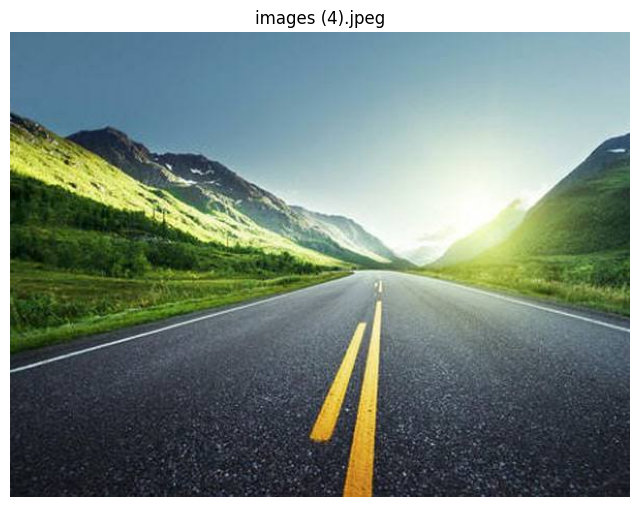

images (4).jpeg -> []



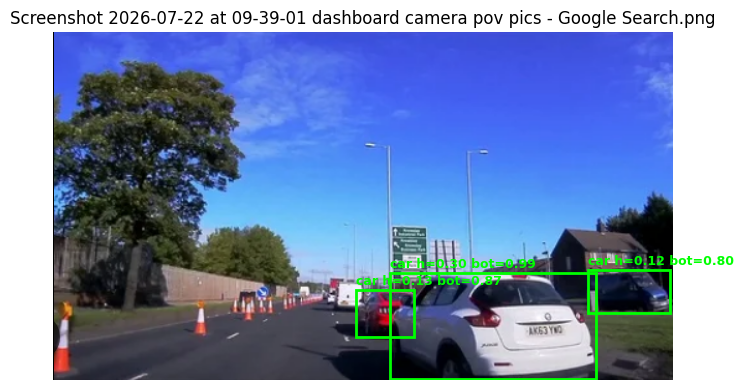

Screenshot 2026-07-22 at 09-39-01 dashboard camera pov pics - Google Search.png -> [{'class': 'car', 'confidence': 0.9236847162246704, 'relative_height': 0.3049986072393129, 'relative_bottom': 0.9948296702580212, 'box': (325.6016845703125, 232.4730682373047, 525.567626953125, 335.2575988769531)}, {'class': 'car', 'confidence': 0.8254483938217163, 'relative_height': 0.1343478420721671, 'relative_bottom': 0.8739786119772348, 'box': (292.9679870605469, 249.2555694580078, 349.0176086425781, 294.5307922363281)}, {'class': 'car', 'confidence': 0.5559276938438416, 'relative_height': 0.12203716878013723, 'relative_bottom': 0.8049373456915337, 'box': (517.7604370117188, 230.13735961914062, 597.1302490234375, 271.2638854980469)}]



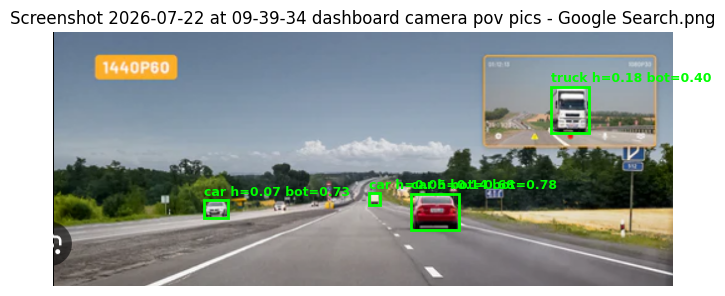

Screenshot 2026-07-22 at 09-39-34 dashboard camera pov pics - Google Search.png -> [{'class': 'car', 'confidence': 0.8054505586624146, 'relative_height': 0.14378374814987183, 'relative_bottom': 0.7788968682289124, 'box': (360.5621032714844, 162.58895874023438, 408.63348388671875, 199.39759826660156)}, {'class': 'truck', 'confidence': 0.5231121182441711, 'relative_height': 0.18233777582645416, 'relative_bottom': 0.3962402045726776, 'box': (501.6287841796875, 54.7590217590332, 539.9407348632812, 101.43749237060547)}, {'class': 'car', 'confidence': 0.4696507751941681, 'relative_height': 0.06806433200836182, 'relative_bottom': 0.7290655970573425, 'box': (152.44766235351562, 169.21632385253906, 176.07089233398438, 186.6407928466797)}, {'class': 'car', 'confidence': 0.4338926374912262, 'relative_height': 0.04781681299209595, 'relative_bottom': 0.6805623173713684, 'box': (318.1025695800781, 161.98284912109375, 329.2370910644531, 174.2239532470703)}]



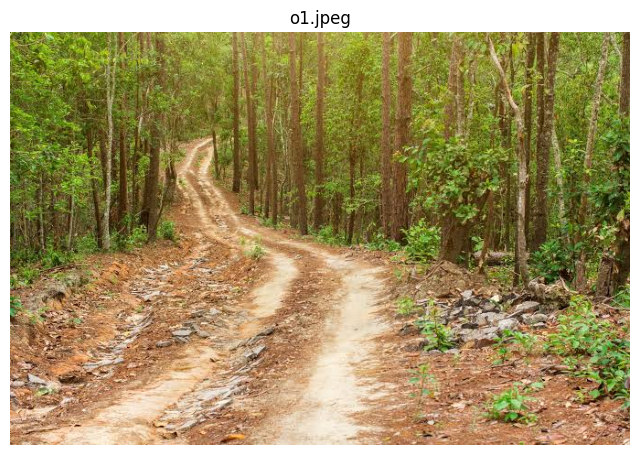

o1.jpeg -> []



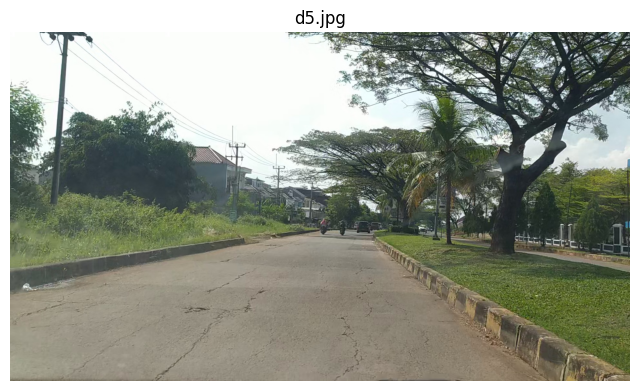

d5.jpg -> []



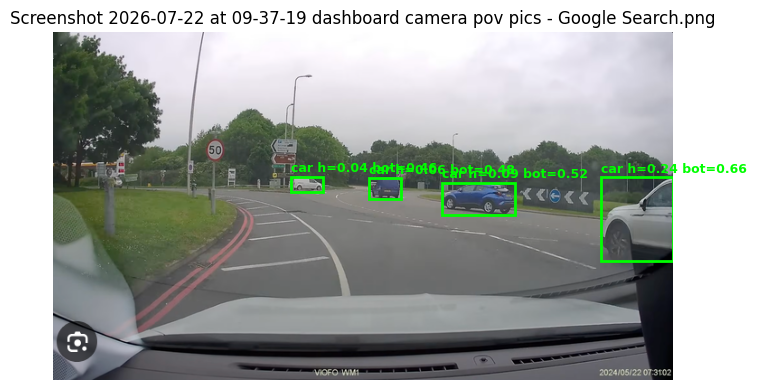

Screenshot 2026-07-22 at 09-37-19 dashboard camera pov pics - Google Search.png -> [{'class': 'car', 'confidence': 0.8729877471923828, 'relative_height': 0.0914377584085836, 'relative_bottom': 0.5231377143364448, 'box': (430.25274658203125, 166.20448303222656, 510.5244445800781, 201.40802001953125)}, {'class': 'car', 'confidence': 0.7759549021720886, 'relative_height': 0.24032148881392046, 'relative_bottom': 0.655812845601664, 'box': (606.6203002929688, 159.96417236328125, 685.6946411132812, 252.48794555664062)}, {'class': 'car', 'confidence': 0.7040748596191406, 'relative_height': 0.04420312658532873, 'relative_bottom': 0.45816468077820616, 'box': (262.87957763671875, 159.3751983642578, 298.9730529785156, 176.39340209960938)}, {'class': 'car', 'confidence': 0.6826829314231873, 'relative_height': 0.0611250047559862, 'relative_bottom': 0.4787856064833604, 'box': (349.87017822265625, 160.79933166503906, 384.5973815917969, 184.33245849609375)}]



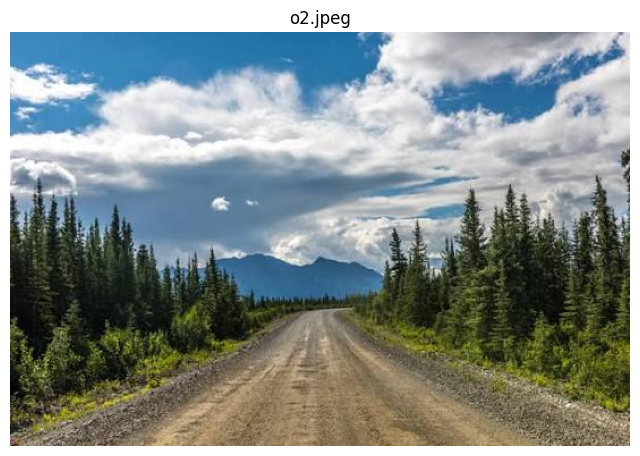

o2.jpeg -> []



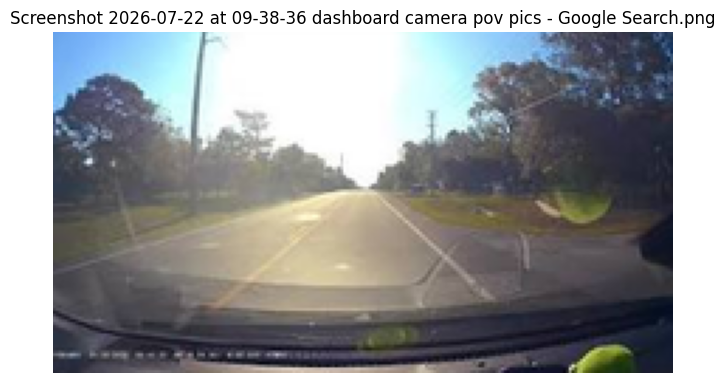

Screenshot 2026-07-22 at 09-38-36 dashboard camera pov pics - Google Search.png -> []



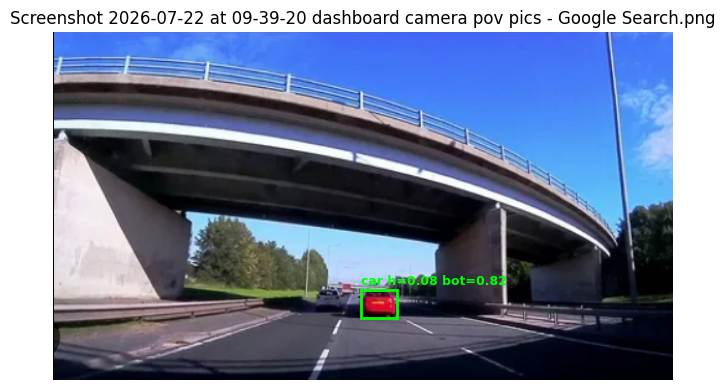

Screenshot 2026-07-22 at 09-39-20 dashboard camera pov pics - Google Search.png -> [{'class': 'car', 'confidence': 0.5113730430603027, 'relative_height': 0.08149755460925909, 'relative_bottom': 0.8217993490066302, 'box': (297.6799621582031, 249.48170471191406, 332.5337219238281, 276.9463806152344)}]



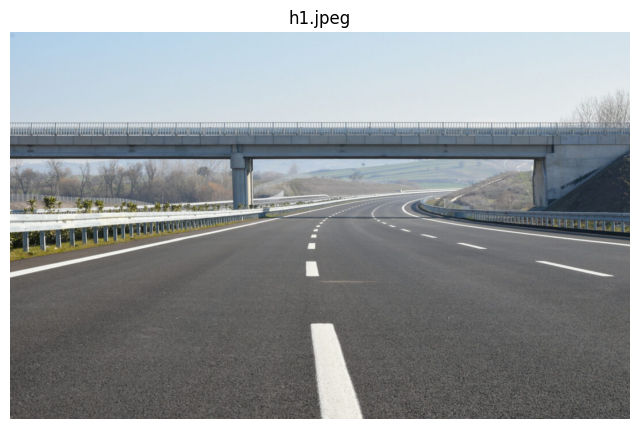

h1.jpeg -> []



In [10]:
def analyze_frame(image_path, show=True):
    img = Image.open(image_path)
    frame_w, frame_h = img.size

    results = vehicle_model.predict(image_path, conf=VEHICLE_CONFIDENCE_THRESHOLD, verbose=False)
    detections = []

    for r in results:
        for box in r.boxes:
            cls_name = vehicle_model.names[int(box.cls[0])]
            if cls_name not in VEHICLE_CLASSES:
                continue
            conf = float(box.conf[0])
            x1, y1, x2, y2 = box.xyxy[0].tolist()

            box_h = y2 - y1
            relative_height = box_h / frame_h
            relative_bottom = y2 / frame_h

            detections.append({
                "class": cls_name,
                "confidence": conf,
                "relative_height": relative_height,
                "relative_bottom": relative_bottom,
                "box": (x1, y1, x2, y2),
            })

    if show:
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(img)
        for d in detections:
            x1, y1, x2, y2 = d["box"]
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor="lime", facecolor="none")
            ax.add_patch(rect)
            label = f"{d['class']} h={d['relative_height']:.2f} bot={d['relative_bottom']:.2f}"
            ax.text(x1, y1 - 5, label, color="lime", fontsize=9, weight="bold")
        ax.set_title(os.path.basename(image_path))
        ax.axis("off")
        plt.show()

    return detections

sample_files = [f for f in os.listdir(SAMPLE_IMAGES_DIR) if f.lower().endswith((".jpg", ".jpeg", ".png"))][:10]

for f in sample_files:
    dets = analyze_frame(os.path.join(SAMPLE_IMAGES_DIR, f))
    print(f, "->", dets)
    print()


## 4. Set your thresholds based on what you just saw
Look back at section 3: find a frame where a car genuinely looks "too close, back off" to your own eye,
note its `relative_height`/`relative_bottom` values, and set the thresholds below to just under that.
The placeholders here are a reasonable starting guess, not a verified answer — that's your job from
section 3's output, not mine.

In [11]:
CLOSE_RELATIVE_HEIGHT_THRESHOLD = 0.30
CLOSE_RELATIVE_BOTTOM_THRESHOLD = 0.80  

## 5. Final detection function

In [12]:
def detect_car_too_close(image_path):
    """
    Returns (too_close: bool, closest_vehicle: dict or None, all_detections: list).
    Heuristic only — not a real metric distance. A vehicle counts as "too close" if EITHER its box is
    tall relative to the frame OR its bottom edge sits low in the frame (closer to the camera).
    """
    img = Image.open(image_path)
    frame_w, frame_h = img.size

    results = vehicle_model.predict(image_path, conf=VEHICLE_CONFIDENCE_THRESHOLD, verbose=False)
    detections = []

    for r in results:
        for box in r.boxes:
            cls_name = vehicle_model.names[int(box.cls[0])]
            if cls_name not in VEHICLE_CLASSES:
                continue
            conf = float(box.conf[0])
            x1, y1, x2, y2 = box.xyxy[0].tolist()

            relative_height = (y2 - y1) / frame_h
            relative_bottom = y2 / frame_h

            detections.append({
                "class": cls_name,
                "confidence": conf,
                "relative_height": relative_height,
                "relative_bottom": relative_bottom,
            })

    close_vehicles = [
        d for d in detections
        if d["relative_height"] >= CLOSE_RELATIVE_HEIGHT_THRESHOLD
        or d["relative_bottom"] >= CLOSE_RELATIVE_BOTTOM_THRESHOLD
    ]

    too_close = len(close_vehicles) > 0
    closest = max(close_vehicles, key=lambda d: d["relative_bottom"], default=None)

    return too_close, closest, detections


## 6. Quick test — run the final function on the same sample frames

In [13]:
for f in sample_files:
    img_path = os.path.join(SAMPLE_IMAGES_DIR, f)
    too_close, closest, dets = detect_car_too_close(img_path)
    print(f"{f}: too_close={too_close}" + (f", closest={closest}" if closest else ""))


images (4).jpeg: too_close=False
Screenshot 2026-07-22 at 09-39-01 dashboard camera pov pics - Google Search.png: too_close=True, closest={'class': 'car', 'confidence': 0.9236847162246704, 'relative_height': 0.3049986072393129, 'relative_bottom': 0.9948296702580212}
Screenshot 2026-07-22 at 09-39-34 dashboard camera pov pics - Google Search.png: too_close=False
o1.jpeg: too_close=False
d5.jpg: too_close=False
Screenshot 2026-07-22 at 09-37-19 dashboard camera pov pics - Google Search.png: too_close=False
o2.jpeg: too_close=False
Screenshot 2026-07-22 at 09-38-36 dashboard camera pov pics - Google Search.png: too_close=False
Screenshot 2026-07-22 at 09-39-20 dashboard camera pov pics - Google Search.png: too_close=True, closest={'class': 'car', 'confidence': 0.5113730430603027, 'relative_height': 0.08149755460925909, 'relative_bottom': 0.8217993490066302}
h1.jpeg: too_close=False
